In [301]:
words = words = open('names.txt', 'r').read().splitlines()

In [302]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [303]:
# since its  abigram language model - we are always looking at only 2 characters at a time

#one character is given , we predict the next character - so its kinda weak. it just looks at a previous chatavyer and predicts the next 



b = {} # dictionary 

# each pair of leters is considered a bigram 
# one simple model we can take here is count the number of times a bigram occurs and store it in a dictionary 
#for eg  ('e', 'm'): 769 means e and the letter m occured together 769 times in the data set
for w in words :
    temp = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(temp, temp[1:]):
        key = (ch1, ch2)
        b[key] = b.get(key, 0)+1


In [304]:
sorted (b.items(), key = lambda kv : -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [305]:
#the above representaion of bigram actually kinda sucks 
# so we are going  to take a 2 dimensional array with each row denoting first letter and column denoting second letter
# each letter has to be mapped to the number in alphabet range right 
# so create stoi whihc maintains the below like a lookup table to generate bigram representation in the form of 2d array later   
#a:1
#b:2
#c:3 

chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)}
stoi.get('z')
stoi['<S>'] = 26 
stoi['<E>'] = 27
len(stoi)

28

In [306]:
import torch

In [307]:
N=torch.zeros((28,28), dtype = torch.int32)

In [308]:

b = {} # dictionary 

#use stoi look up table and fill the 2 dimensional matrix like shown below 
for w in words :
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        ind1 = stoi[ch1]
        ind2 = stoi[ch2]
        N[ind1,ind2] += 1 


        

In [309]:
import matplotlib.pyplot as plt

In [310]:
%matplotlib inline

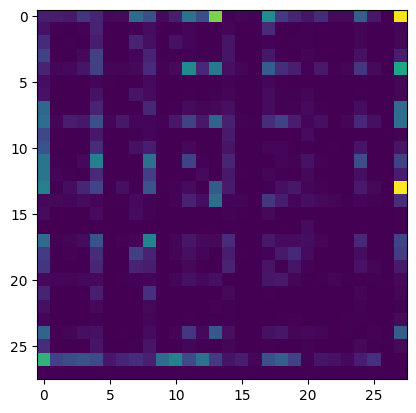

In [311]:
plt.imshow(N)

In [312]:
#to make the above 2 dimensional array look pretty andrej wrote a code 
#step 1 is to get the reverse itos of stoi

itos = {i:s for s,i in stoi.items()}

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

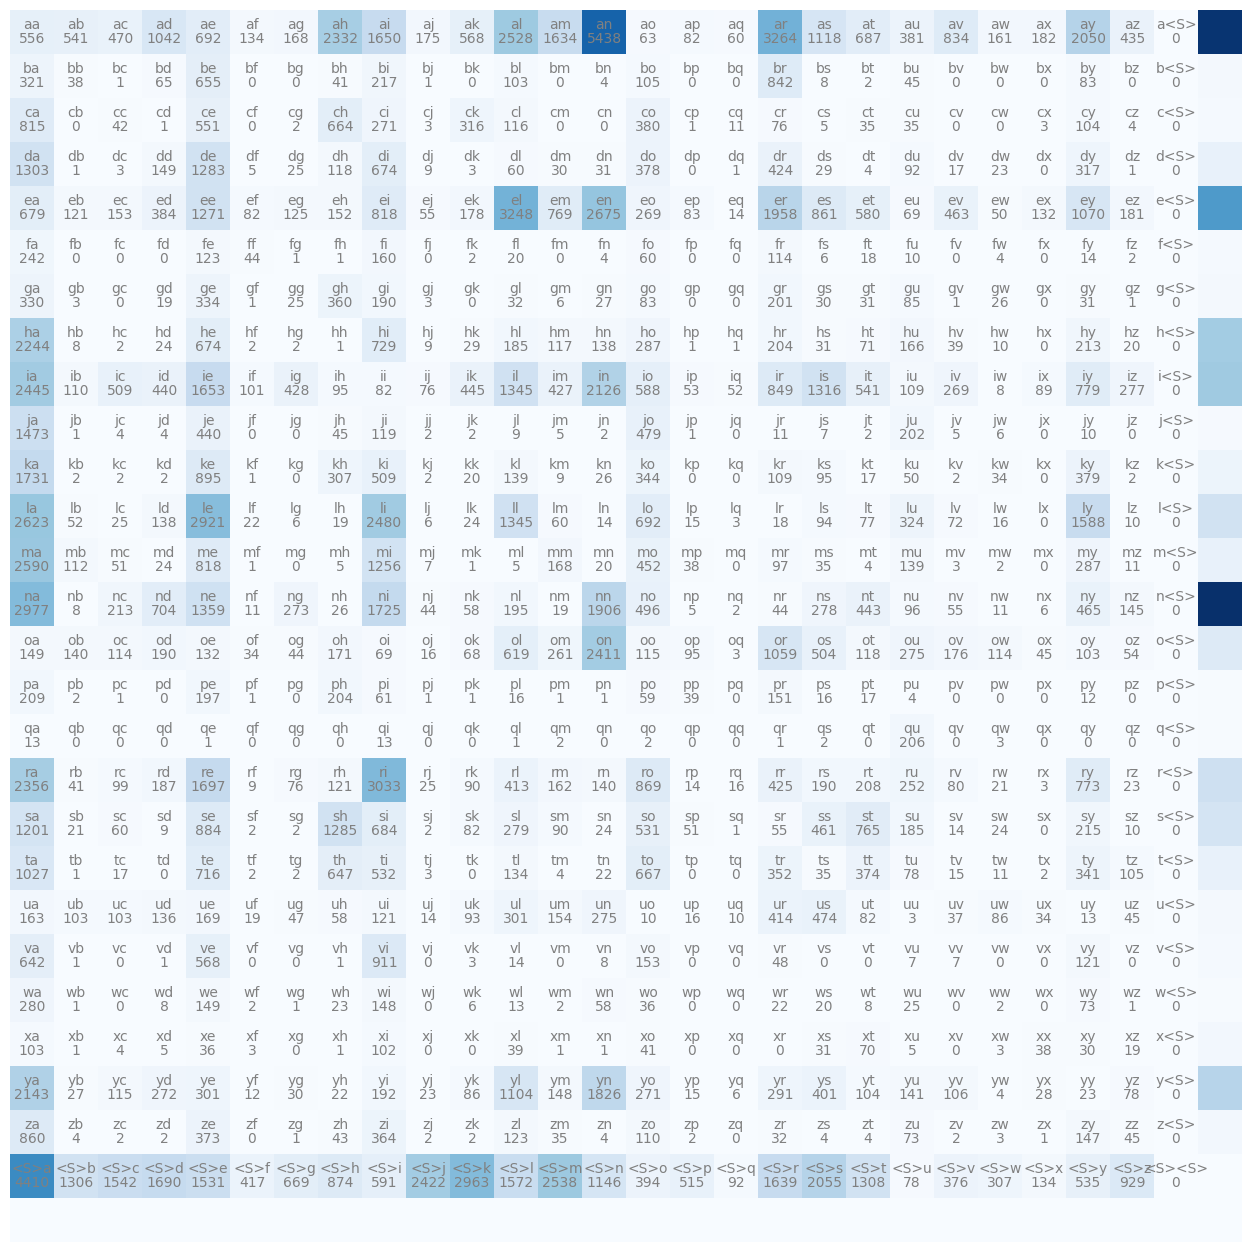

In [313]:
# JUST FOR BETTER VISUALISATION
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27): # traversing through each row in N - first leter of bigram
    for j in range(27): #traversing through each column in the row that you have chosen - second letter in the bigram 
        chstr = itos[i] + itos[j] #convert the row or column number into the character that it represents - row 0, column 0 represents the bigram aa- like that
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray') # N[i, j].item() gives the count 
plt.axis('off')

In [314]:
#the problem with above graph is there is one entire row 
#of <E> that is 0 and one entire row of column for <S> 
#that is going ot be 0 because <E> denotes end of word 
#and will not have anything next to it and <s> denotes 
#the start of word and cannot come next to some word - it is 
#always going to be the first character in a bigram - so the 
#column which says its 
#next to something will always be a 0, hence this is waste of space 

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

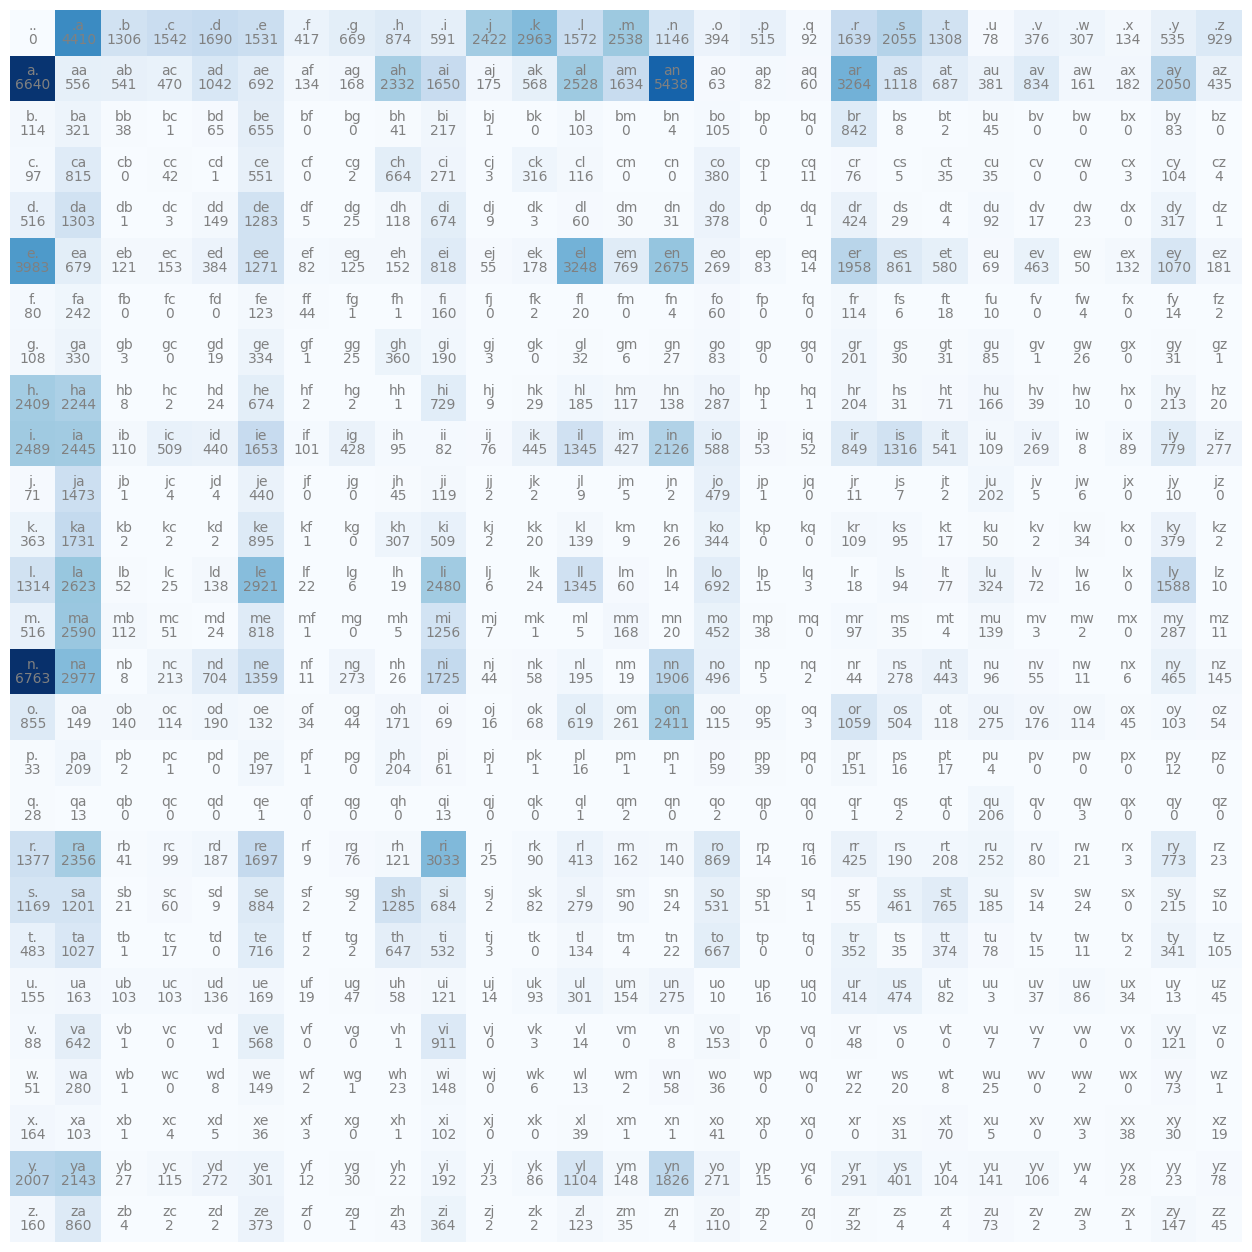

In [315]:
# to fix, lets redesign stuff 
#both start and stop is represented as . --> if . comes first then its start and if it comes second then its last 


#enumerate(chars) will give [(0,a), (1,b), (2,c)...]
chars = sorted(list(set(''.join(words))))
stoi = {char:index+1 for index, char in enumerate(chars)}
stoi['.'] = 0

itos={ind: char for char, ind in stoi.items()}



#now itos and stoi is ready 

N= torch.zeros((27,27), dtype=torch.int32)
for word in words:
    tmp = ['.']+ list(word)+['.']
    for chr1, chr2  in zip(tmp, tmp[1:]):
        ind1 = stoi[chr1]
        ind2 = stoi[chr2]
        N[ind1, ind2] +=1

# JUST FOR BETTER VISUALISATION
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27): # traversing through each row in N - first leter of bigram
    for j in range(27): #traversing through each column in the row that you have chosen - second letter in the bigram 
        chstr = itos[i] + itos[j] #convert the row or column number into the character that it represents - row 0, column 0 represents the bigram aa- like that
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray') # N[i, j].item() gives the count 
plt.axis('off')
        

In [316]:
#now we have count array 
# to convert into probabality , you should divide by sum of all counts 

p=N[0].float()
p=p/p.sum() #to create a probability distribution 
p

#now p is the probabalities of each letter starting the word because we took the first row 

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [317]:
#since its the probablities 
p.sum()

tensor(1.)

In [318]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
print(itos[ix])

#since p is on N[0], 0th row , 0th row tells us the probablities of each letter to occur as the first letter in the row 
# we converted the counts presnt in first row into probabilties
# asked torch.multinomial to pick up random letter in that probability distribution, first time it returned 3 
#each row represents the first letter of bigram 
# each column represents the second letter of bigram 
# so 3 just means c has been picked by torch.multinomial-
# now if c is the first character - we hvae to go to row number 3 and based on that probablity distribution, ask torch.polynomial to pick up the next letter -

p = N[ix].float()
p = p/p.sum()
ix2 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
print(itos[ix2])


p = N[ix2].float()
p = p/p.sum()
ix3 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
print(itos[ix3])

p = N[ix3].float()
p = p/p.sum()
ix4 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
print(itos[ix4])

#similarly continued for 4 letters of the word. now lets convert this into a loop  


c
e
x
z


In [319]:
#now lets convert this into a loop 

ix = 0

for i in range(20): # to geenrate 20 different words 
    output = []
    while True:
        p = N[ix].float() # strip each row 
        p=p/p.sum() # find probabilities for this particular dataset - these probabilities come from this data set 
        #if you want to give equal probabilities to every character, then the distribution is called uniform distribution and then we can sample from that - this is what it means to pick words from an untrained model where every character is equally likely  
        #p=torch.ones(27) /27.0 # see this output will look really ugly 
        ix = torch.multinomial(p, num_samples = 1, replacement=True, generator = g).item()
        output.append(itos[ix])
        if  ix == 0:
            break
    
    print(''.join(output))


# this loop lowkey feels inefficient because you everytime do the same thing - pick each row, normalise it to find the probabilities and then sample from that probability to find the next character 
# might as well create a matrix of same size with probabilities pre calculated 
    

malemasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.


In [328]:
#to mimic that loop with pre calculated probablities - first we have to understand few operations 
#this block is to understand how torch.sum works with keepdim = true /false

#just know that input dimension lets say is 27* 27 , P.sum(0,27) will return a tensor back of shape 1,27 ====> this 27* 27  becomes 1,27 thats it
# if keepdim = false then input of size 27*27  becomes [27] 
P = N.float()

P.shape

P.sum(0, keepdim =True).shape # summing by row axis which means the final output row will contain the sum of each column- ehre keepdim = True means only the 0th axis becomes 1 and rest of the dimensions are maintained - that's why this shape is still [1,27]

P.sum(0, keepdim =False).shape # does the same but does not retain the dimensions of P - it just returns a single dimensional array vector with 27 elements each representing the sum of that particular column 

P.sum(1, keepdim =True) # summing by column axis which means the final output column will contain the sum of each row



tensor([[32033.],
        [33885.],
        [ 2645.],
        [ 3532.],
        [ 5496.],
        [20423.],
        [  905.],
        [ 1927.],
        [ 7616.],
        [17701.],
        [ 2900.],
        [ 5040.],
        [13958.],
        [ 6642.],
        [18327.],
        [ 7934.],
        [ 1026.],
        [  272.],
        [12700.],
        [ 8106.],
        [ 5570.],
        [ 3135.],
        [ 2573.],
        [  929.],
        [  697.],
        [ 9776.],
        [ 2398.]])

In [332]:
# now we understand how torch.sum works 

# lets understand how to pre store the probabilities in the matrix

P = N.float() # N has all the counts ==> P is of shape 27 x 27

# now we need to mimic p=p/p.sum()

P /= P.sum(1, keepdim=True) 

P[0].sum() # should return 1 because it has probabililty distribution in its row 

tensor(1.)

In [333]:



# to know whether a binary operation like division can work on 2 tensors like P = P/P.sum(1, keepdim=True), we need to understand the broadcasting semantics reallly well 

#according to documentation : When iterating over the dimension sizes, starting at the trailing dimension, 
#the dimension sizes must either be equal, one of them is 1, or one of them does not exist.

# lets take 
#P shape                  is 27 x 27 
#P.sum(1, keepdim=True)   is 27 x 1 
# start arranging eerything together from right to left 
#P shape                  is 27 x 27 
#P.sum(1, keepdim=True)   is 27 x 1 
# then check from right to left for the rules 
#27 x  27 
#27 x  1
#      ^
#      | 

#check for 27, 1 ->is good because either of them is 1 

#27 x  27 
#27 x  1
#^
#| 

#CHECK FOR  27 27 -> is good because they are equal
#so broadcasting is possible here

#p.sum with shape  27  x 1 will be broadcasted to each and every column in 27 x 27 matrix, each element will be divided by the sum of values of its row . the row that it is present in 


# ok very very very important lesson here - we need to understand and respect https://docs.pytorch.org/docs/2.12/notes/broadcasting.html - Andrej stressed that this is very important because this might lead to a lot of bugs. andrej even asked to spend some time on tutorials separately
#andrej mentioned that we hsould learn how it works under the hood also :) 
#small excercise - will the answer be same if P = P/P.sum(1, keepdim=False) - what will happen here 



In [335]:
# now rewrite this loop with the newly formed probability matrx

ix = 0
g = torch.Generator().manual_seed(2147483647)

for i in range(5): # to geenrate 20 different words 
    output = []
    while True:
        p = P[ix]
        #p = N[ix].float() 
        #p=p/p.sum() 
        ix = torch.multinomial(p, num_samples = 1, replacement=True, generator = g).item()
        output.append(itos[ix])
        if  ix == 0:
            break
    
    print(''.join(output))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [370]:
#summary until now : we trained a bigram language model 
# how did we train : by just counting how frequently all pairings occur , normalising them into a probability distribution
#elements of array P are paramaters of our bigram language model - it contains information and statistics on what occurs next to what 


# now i want to evaluate the quality of the model - a single number that represents how good the model is at predicting the training set 

#LOSS ---> 

#same code we used for counting and creating our N matrix 
log_likelihood = 0.0
n=0
N= torch.zeros((27,27), dtype=torch.int32)
for word in words:
    tmp = ['.']+ list(word)+['.']
    for chr1, chr2  in zip(tmp, tmp[1:]):
        ind1 = stoi[chr1]
        ind2 = stoi[chr2]
        prob = P[ind1, ind2]
        #likelihood = product of all individual probabilities 
        #log likelihood  =  sum of log of individual probabilities 
        logprob = torch.log(prob) #this is mostly for convenience 
        log_likelihood += logprob #(because log likelihood == log (p1*p2*p3) =  log(p1)+log(p2)+log(p3))
        n+=1 # to take avergae later 
        #print(f'{chr1}{chr2} : {prob:.4f} {logprob :.4f}')


print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')
#2.424102306365967 is our loss function assigned for the training set by our model 
#job of training is to find parameters that reduce the loss nll/n

log_likelihood=tensor(-559891.7500)
nll=tensor(559891.7500)
2.454094171524048


In [375]:

"""

my notes : rish:
prob = P[ind1, ind2] has 

.e : 0.0478
em : 0.0377
mm : 0.0253
ma : 0.3899
a. : 0.1960
.o : 0.0123
ol : 0.0780
li : 0.1777
iv : 0.0152
vi : 0.3541
ia : 0.1381
a. : 0.1960

this is the probability of those bigrams occuring in the data set 

if all the characters are equally likely to occur , (there are 27 characters , ) so tha probability will be 1/27 = 0.03==> ~0.04 ===> ~4% 
if any probability is more than that 4 % , then we consider that this bigram model is giving some useful information 

say for eg : vi is higher than 4% -->it is 35%

so the model is already trained and it has parameters in P and you are passing emma, olivia etc now which are already in the trainign st- if its a good model and we pass samples from trainign set- 
probability should  have closer to 1 for all the above values- this means that your model is correctly predicitng what comes next especially the ones in the training model

how can we summarise these probabilities INTO A SINGLE number that measures the quality of this model ???

ps: refer to MAXIMUM LIKELIHOOD ESTIMATION , STATISTICAL MODELING in wikipedia quick read  -- 

how can we summarise these probabilities INTO A SINGLE number that measures the quality of this model ??? --> likelihoood 

likelihood is the product of all the above probabilities - it tells us the probability of entire data set assigned by our model that we have trained - that is the measure of quality 

so the product of probabilities should be really high - the likelihood should be really high if its a good model 

for convenience, we use log likelihood because the product of probabilities would be very small 

https://www.wolframalpha.com/input?i=log%28x%29+from+0+to+1

if probability is 1 
log(probability) = log(1) = 0 

log ( some lower probablity) = negative numbers and it goes lower 


likelihood is the product of all probabilities 

log likelihood log (p1*p2*p3) =  log(p1)+log(p2)+log(p3)

but this doesnt follow the rule that less loss is good, more loss is bad - so we take the negative of if 

which is negative log likelihood  =  negative of log likelihood 
negative log likelihood  is a good loss function because the more nll, the loss is more, hence the model is badly performing - we need to bring nll down so that the loss is lesser which in turn means the model is performing better 

negative log likelihood in practical life people take an average instead of  sum to normalise it - hence 2.454094171524048



"""

'\n\nmy notes : rish:\nprob = P[ind1, ind2] has \n\n.e : 0.0478\nem : 0.0377\nmm : 0.0253\nma : 0.3899\na. : 0.1960\n.o : 0.0123\nol : 0.0780\nli : 0.1777\niv : 0.0152\nvi : 0.3541\nia : 0.1381\na. : 0.1960\n\nthis is the probability of those bigrams occuring in the data set \n\nif all the characters are equally likely to occur , (there are 27 characters , ) so tha probability will be 1/27 = 0.03==> ~0.04 ===> ~4% \nif any probability is more than that 4 % , then we consider that this bigram model is giving some useful information \n\nsay for eg : vi is higher than 4% -->it is 35%\n\nso the model is already trained and it has parameters in P and you are passing emma, olivia etc now which are already in the trainign st- if its a good model and we pass samples from trainign set- \nprobability should  have closer to 1 for all the above values- this means that your model is correctly predicitng what comes next especially the ones in the training model\n\nhow can we summarise these probabil

In [376]:
#summary of everything 

#1. we need to find one single number which tells you how good or bad your model is 
#2. that is represented by likelihood 
#3. GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling) --> meaning adjust parameters to maximise the likelihood 
# equivalent to maximizing the log likelihood (because log is monotonic) # log( likelihood ) is just scaling the likelihood so its the same as maximising the likelihood 
# equivalent to minimizing the negative log likelihood 
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [163]:
#sampling from this distribution  using torch multinomial means
#
#torch.multinomial says you give me the probabilities 
#I will give you integers sampled accordinv to 
#that probablity distribution


# this is an example block to understand torch.multinomial 


g = torch.Generator().manual_seed(2147483647) # this makes everything deterministic - output on my computer will be same as andrej's
p = torch.rand(3, generator = g)
p = p/p.sum()
p

#p gives tensor([0.6064, 0.3033, 0.0903])




tensor([0.6064, 0.3033, 0.0903])

In [143]:
torch.multinomial(p, num_samples=20, replacement=True, generator =g)


#tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])
#what this output means is 
#p is tensor([0.6064, 0.3033, 0.0903])
#so the probability of 0 occuring is 0.6064 which means ~60% chance - highest 
#probablitiy of 1 occuring is 0.3033,which means 30%
#probability of 1 occuring is 9.03%

#so if you do torch.polynomial on a probability distribution like this using syntax : torch.multinomial(p, num_samples=20, replacement=True, generator =g)
#you can see that 0 occured 9 times , 1 occured 9 times , 2 occured only 2 times
# 2 occured only twice just like it should have 

#this is what multinomial does 
 


tensor([0, 0, 0, 2, 0, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])